# Decision: ESP Interpolation Strategy

**Status:** Resolved — **Multiquadric RBF**
**Decision made:** See `THESISPROCESSES.md`

**Protein:** AF-Q16613-F1 (medium, ~30 500 vertices)
**Sampling:** Curvature-weighted, 5% of vertices (k=1,524)

## Problem
After curvature-weighted subsampling, the model receives ESP values only at the ~1,524 query vertices. To evaluate reconstruction quality and produce a dense training target for the full mesh, the sparse predictions must be interpolated back to all ~30,482 vertices. Three methods are compared:

| Method | Description |
|--------|-------------|
| **Nearest Neighbor (1-NN)** | Each vertex inherits the ESP of its closest sampled vertex |
| **Gaussian RBF** | `φ(r) = exp(−(ε·r)²)`, ε = 1 / mean nearest-neighbour distance among sampled vertices |
| **Multiquadric RBF** | `φ(r) = √(1 + (ε·r)²)`, same ε definition |

RBF methods use `RBFInterpolator(neighbors=RBF_NEIGHBORS)` for local support.

---

## Conclusion

**Decision: Multiquadric RBF.**

At the 5% curvature-weighted sample (k=1,524), multiquadric RBF achieves r=0.983 and RMSE=0.466 kT/e — a 39% reduction in RMSE over 1-NN (0.766 kT/e) and a meaningful improvement over Gaussian RBF (0.548 kT/e). Both RBF methods take ~1.12s at this scale; multiquadric is chosen for its superior accuracy at identical cost.

**Key findings:**
- 1-NN gives r=0.954, adequate but leaves ~0.77 kT/e average reconstruction error. Each vertex inherits its nearest sample's value with no spatial interpolation, producing blocky transitions at sample boundaries.
- Gaussian RBF improves to r=0.978 / RMSE=0.548 kT/e. The Gaussian kernel (exp(−(εr)²)) decays rapidly, providing local but smooth interpolation.
- Multiquadric RBF achieves the best result: r=0.983 / RMSE=0.466 kT/e. The multiquadric basis (√(1+(εr)²)) decays more slowly than Gaussian, better capturing the longer-range character of ESP fields between widely-spaced samples.
- Both RBF methods are ~230× slower than 1-NN (1.12s vs 0.005s). For a preprocessing step run once per protein, this is acceptable. It is not suitable for use in real-time inference or tight training loops.

**Decision recorded in:** `THESISPROCESSES.md`

In [1]:
# ── Display setup ─────────────────────────────────────────────────────────────
import os
os.environ.setdefault("DISPLAY", ":0")
os.environ.setdefault("WAYLAND_DISPLAY", "wayland-0")
os.environ.setdefault("XDG_RUNTIME_DIR", "/mnt/wslg/runtime-dir")

'/run/user/1000/'

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
import pyvista as pv
from IPython.display import display as ipy_display, Image as ipy_Image
import PIL.Image, io

pv.set_jupyter_backend("static")

PROJECT_ROOT = Path("../").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_config, get_data_root

cfg       = get_config()
data_root = get_data_root()
print("data_root:", data_root)

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
PROTEIN_ID    = "AF-Q16613-F1"
SAMPLE_FRAC   = 0.05         # curvature-weighted subsample fraction
RBF_NEIGHBORS = 50           # local support for RBFInterpolator
RNG_SEED      = 42

print(f"Protein         : {PROTEIN_ID}")
print(f"Sample fraction : {SAMPLE_FRAC*100:.1f}%")
print(f"RBF neighbours  : {RBF_NEIGHBORS}")

Protein         : AF-Q16613-F1
Sample fraction : 5.0%
RBF neighbours  : 50


---
## Load PQR Mesh and ESP Ground Truth

Vertices are loaded directly from the saved `pqr_mesh.npz` in their original MSMS order.
ESP ground truth is loaded from `pqr_mesh_interp.npz` (pre-computed by pipeline stage 04).


In [ ]:
# ── Load PQR mesh and ESP ground truth ────────────────────────────────────────
pid = PROTEIN_ID

protein_dir     = data_root / pid
pqr_mesh_path   = protein_dir / "mesh" / f"{pid}_pqr_mesh.npz"
esp_interp_path = protein_dir / "esp"  / f"{pid}_pqr_mesh_interp.npz"

d        = np.load(pqr_mesh_path)
verts    = d["verts"].copy()     # float32 (N, 3) — original MSMS order
faces    = d["faces"].copy()     # int64   (F, 3)
ses_area = float(d["ses_area"])

esp_gt = np.load(esp_interp_path)["esp_verts"]   # float32 (N,)

print(f"{pid}")
print(f"  Vertices  : {len(verts):,}")
print(f"  Faces     : {len(faces):,}")
print(f"  SES area  : {ses_area:,.0f} Å²")
print(f"  ESP range : [{esp_gt.min():.2f}, {esp_gt.max():.2f}] kT/e")

---
## Vertex Curvature (Cotangent Laplacian)

Mean curvature magnitude `H_i = ‖L·verts‖₂` (row-wise norm of the cotangent-weighted
Laplacian applied to vertex positions).  Used as sampling probability weights.

In [5]:
# ── Vectorized cotangent-Laplacian curvature ─────────────────────────────────

def vertex_curvature_fast(verts: np.ndarray, faces: np.ndarray) -> np.ndarray:
    """Vectorized cotangent-Laplacian mean curvature magnitude."""
    n = len(verts)
    all_rows, all_cols, all_w = [], [], []
    for i in range(3):
        v0, v1, v2 = faces[:, i], faces[:, (i+1)%3], faces[:, (i+2)%3]
        a = verts[v1] - verts[v0]
        b = verts[v2] - verts[v0]
        cross_norm = np.linalg.norm(np.cross(a, b), axis=1)
        dot        = np.einsum("ij,ij->i", a, b)
        valid      = cross_norm > 1e-12
        cot        = np.where(valid, dot / np.where(valid, cross_norm, 1.0), 0.0)
        all_rows  += [v1, v2]
        all_cols  += [v2, v1]
        all_w     += [cot, cot]
    rows_  = np.concatenate(all_rows)
    cols_  = np.concatenate(all_cols)
    w_     = np.concatenate(all_w)
    L_off  = sp.coo_matrix((w_, (rows_, cols_)), shape=(n, n)).tocsr()
    diag   = -np.array(L_off.sum(axis=1)).flatten()
    L      = L_off + sp.diags(diag)
    return np.linalg.norm(L @ verts, axis=1).astype(np.float32)

t0   = time.perf_counter()
curv = vertex_curvature_fast(verts, faces)
print(f"Curvature: {time.perf_counter()-t0:.1f}s  range [{curv.min():.2f}, {curv.max():.2f}]")

Curvature: 0.0s  range [0.00, 3.25]


---
## Curvature-Weighted Sampling

Vertices are sampled with probability proportional to curvature magnitude.
High-curvature regions (pockets, ridges) are sampled more densely.

In [6]:
# ── Curvature-prioritised sampler with minimum spacing ──────────────────

def sample_curvature(
    verts: np.ndarray,
    curv: np.ndarray,
    k: int,
    ses_area: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, float]:
    """
    Curvature-prioritised sampling with minimum spacing.
    Vertices are visited in descending curvature order (high-curvature regions
    are selected first); a vertex is accepted only if no already-selected
    vertex lies within radius r.  r is estimated from SES area and target k:
    r = sqrt(SES_area / π·k).  If the greedy priority pass yields fewer than k
    vertices, remaining slots are filled from the rejected pool (still in
    curvature order) with no spacing constraint.
    """
    t0 = time.perf_counter()
    n  = len(verts)
    k  = min(k, n)

    r    = np.sqrt(ses_area / (np.pi * k))
    r2   = float(r * r)
    cs   = float(r) + 1e-9          # cell size = r → only ±1 neighbours needed
    mins = verts.min(axis=0)

    offsets = [(ox, oy, oz)
               for ox in (-1, 0, 1)
               for oy in (-1, 0, 1)
               for oz in (-1, 0, 1)]

    # Visit order: descending curvature; ties broken by rng
    noise       = rng.random(n) * 1e-9
    visit_order = np.argsort(-(curv + noise))

    grid_h   = {}
    selected = []
    rejected = []

    for idx in visit_order:
        vx = float(verts[idx, 0])
        vy = float(verts[idx, 1])
        vz = float(verts[idx, 2])
        cx = int((vx - mins[0]) / cs)
        cy = int((vy - mins[1]) / cs)
        cz = int((vz - mins[2]) / cs)

        ok = True
        for ox, oy, oz in offsets:
            pts = grid_h.get((cx + ox, cy + oy, cz + oz))
            if pts is None:
                continue
            for px, py, pz in pts:
                if (vx - px)**2 + (vy - py)**2 + (vz - pz)**2 < r2:
                    ok = False
                    break
            if not ok:
                break

        if ok:
            selected.append(idx)
            cell = (cx, cy, cz)
            if cell in grid_h:
                grid_h[cell].append((vx, vy, vz))
            else:
                grid_h[cell] = [(vx, vy, vz)]
            if len(selected) == k:
                break
        else:
            rejected.append(idx)

    # Fill remaining slots from rejected pool (curvature order preserved)
    if len(selected) < k:
        need = k - len(selected)
        selected.extend(rejected[:need])
        print(f"  Curvature: spacing-pass gave {len(selected) - need} / {k} — "
              f"filled {need} from rejected pool")

    return np.sort(np.array(selected, dtype=np.int64)), time.perf_counter() - t0

print("Curvature sampler ready.")


Curvature sampler ready.


---
## Interpolation Methods

Each function accepts the full vertex array, the known (sampled) ESP values,
and the sampled vertex indices.  It returns reconstructed ESP at **all** vertices
plus wall-clock time for the interpolation step.

**ε (epsilon)** = `1 / mean nearest-neighbour distance among sampled vertices`.  
This scales the RBF kernel to transition at the typical inter-sample spacing.

In [7]:
# ── Epsilon helper ────────────────────────────────────────────────────────────

def _rbf_epsilon(known_verts: np.ndarray) -> float:
    """1 / mean nearest-neighbour distance among known vertices."""
    tree = cKDTree(known_verts)
    dists, _ = tree.query(known_verts, k=2, workers=-1)  # k=2: skip self
    return 1.0 / max(float(dists[:, 1].mean()), 1e-9)


# ── Interpolation functions ────────────────────────────────────────────────────

def interp_nearest_neighbor(
    verts: np.ndarray, esp_known: np.ndarray, sample_idx: np.ndarray,
) -> tuple[np.ndarray, float]:
    """1-NN: each vertex inherits the ESP of its closest sampled vertex."""
    t0 = time.perf_counter()
    tree = cKDTree(verts[sample_idx])
    _, nn = tree.query(verts, k=1, workers=-1)
    return esp_known[nn].astype(np.float32), time.perf_counter() - t0


def interp_gaussian_rbf(
    verts: np.ndarray, esp_known: np.ndarray, sample_idx: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Gaussian RBF: φ(r) = exp(−(ε·r)²)."""
    t0  = time.perf_counter()
    kv  = verts[sample_idx].astype(np.float64)
    eps = _rbf_epsilon(kv)
    rbf = RBFInterpolator(
        kv, esp_known.astype(np.float64),
        kernel="gaussian", epsilon=eps, neighbors=RBF_NEIGHBORS,
    )
    return rbf(verts.astype(np.float64)).astype(np.float32), time.perf_counter() - t0


def interp_multiquadric_rbf(
    verts: np.ndarray, esp_known: np.ndarray, sample_idx: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Multiquadric RBF: φ(r) = √(1 + (ε·r)²)."""
    t0  = time.perf_counter()
    kv  = verts[sample_idx].astype(np.float64)
    eps = _rbf_epsilon(kv)
    rbf = RBFInterpolator(
        kv, esp_known.astype(np.float64),
        kernel="multiquadric", epsilon=eps, neighbors=RBF_NEIGHBORS,
    )
    return rbf(verts.astype(np.float64)).astype(np.float32), time.perf_counter() - t0


# ── Metric computation ─────────────────────────────────────────────────────────

def compute_metrics(
    esp_gt: np.ndarray,
    esp_interp: np.ndarray,
    interp_time: float,
) -> dict:
    r, _  = pearsonr(esp_gt.astype(float), esp_interp.astype(float))
    rmse  = float(np.sqrt(np.mean((esp_gt - esp_interp) ** 2)))
    return {
        "esp_pearson_r": round(float(r), 4),
        "esp_rmse":      round(rmse, 4),
        "time_interp_s": round(interp_time, 5),
    }


INTERP_METHODS = [
    ("nearest_neighbor", interp_nearest_neighbor),
    ("gaussian_rbf",     interp_gaussian_rbf),
    ("multiquadric_rbf", interp_multiquadric_rbf),
]

print("Interpolation methods defined.")

Interpolation methods defined.


---
## Run Interpolation Methods at 5%

In [8]:
# ── Sample once, run all three methods ──────────────────────────────────────
rng       = np.random.default_rng(RNG_SEED)
k         = max(1, round(SAMPLE_FRAC * len(verts)))
sample_idx, _ = sample_curvature(verts, curv, k, ses_area, rng)
esp_known = esp_gt[sample_idx]
print(f"k = {k:,} of {len(verts):,} vertices ({SAMPLE_FRAC*100:.1f}%)")

rows = []
for method_name, method_fn in INTERP_METHODS:
    esp_interp, t = method_fn(verts, esp_known, sample_idx)
    m = compute_metrics(esp_gt, esp_interp, t)
    rows.append({'method': method_name, 'k': k, **m})
    print(f"  {method_name:20s}  r={m['esp_pearson_r']:.4f}  "
          f"rmse={m['esp_rmse']:.4f}  t={m['time_interp_s']:.3f}s")

df = pd.DataFrame(rows)

k = 1,524 of 30,482 vertices (5.0%)
  nearest_neighbor      r=0.9540  rmse=0.7658  t=0.005s
  gaussian_rbf          r=0.9775  rmse=0.5484  t=1.143s
  multiquadric_rbf      r=0.9828  rmse=0.4662  t=1.121s


---
## Results Table

In [9]:
# ── Full results table ────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.4f}".format)
df

,method,k,esp_pearson_r,esp_rmse,time_interp_s
0,nearest_neighbor,1524,0.9540,0.7658,0.0047
1,gaussian_rbf,1524,0.9775,0.5484,1.1425
2,multiquadric_rbf,1524,0.9828,0.4662,1.1214


---
## Metric Comparison

Bar chart comparing the three methods at the 5% curvature-weighted sample.

Saved → ../../outputs/AF-Q16613-F1_interpolation_metrics.png


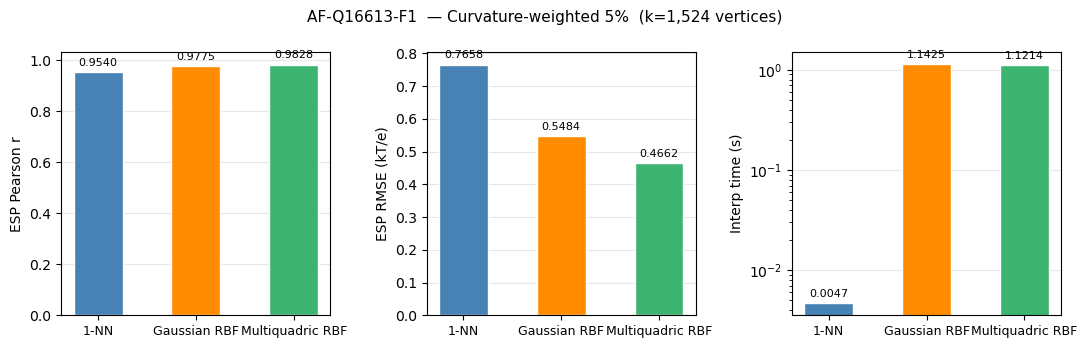

In [10]:
# ── Bar chart comparison ────────────────────────────────────────────────────
METHOD_COLORS = {
    "nearest_neighbor": "steelblue",
    "gaussian_rbf":     "darkorange",
    "multiquadric_rbf": "mediumseagreen",
}
METHOD_LABELS = {
    "nearest_neighbor": "1-NN",
    "gaussian_rbf":     "Gaussian RBF",
    "multiquadric_rbf": "Multiquadric RBF",
}
METRICS = [
    ("esp_pearson_r", "ESP Pearson r",   False),
    ("esp_rmse",      "ESP RMSE (kT/e)", False),
    ("time_interp_s", "Interp time (s)", True),
]

OUT_DIR = Path("../../outputs")
OUT_DIR.mkdir(exist_ok=True)

methods = df['method'].tolist()
x       = range(len(methods))
labels  = [METHOD_LABELS[m] for m in methods]
colors  = [METHOD_COLORS[m] for m in methods]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
fig.suptitle(f"{PROTEIN_ID}  — Curvature-weighted 5%  (k={k:,} vertices)", fontsize=11)

for ax, (col, ylabel, logy) in zip(axes, METRICS):
    vals = df[col].tolist()
    bars = ax.bar(x, vals, color=colors, width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='{:.4f}', fontsize=8, padding=3)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale('log')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
out_path = OUT_DIR / f"{PROTEIN_ID}_interpolation_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Saved → {out_path}")
plt.show()

---
## Visualisation — Interpolation Quality at 5%

**Row 0:** Ground truth ESP on the full mesh.  
**Rows 1–3:** Each method's reconstruction + absolute error heatmap.  
Sampled vertices (curvature-weighted 5%) shown as black spheres.

In [11]:
# ── Visualisation settings ────────────────────────────────────────────────────
CLIM     = (-10, 10)
ERR_CLIM = (0, 5)
COLORMAP = "RdBu_r"
ERR_CMAP = "hot_r"
CAMERA   = "iso"

k=1,524 of 30,482 vertices (5.0%)
  1-NN                  r=0.9540  rmse=0.7658  t=0.00s
  Gaussian RBF          r=0.9775  rmse=0.5484  t=1.14s
  Multiquadric          r=0.9828  rmse=0.4662  t=1.03s
Saved → ../../outputs/AF-Q16613-F1_interpolation_viz_5pct.png


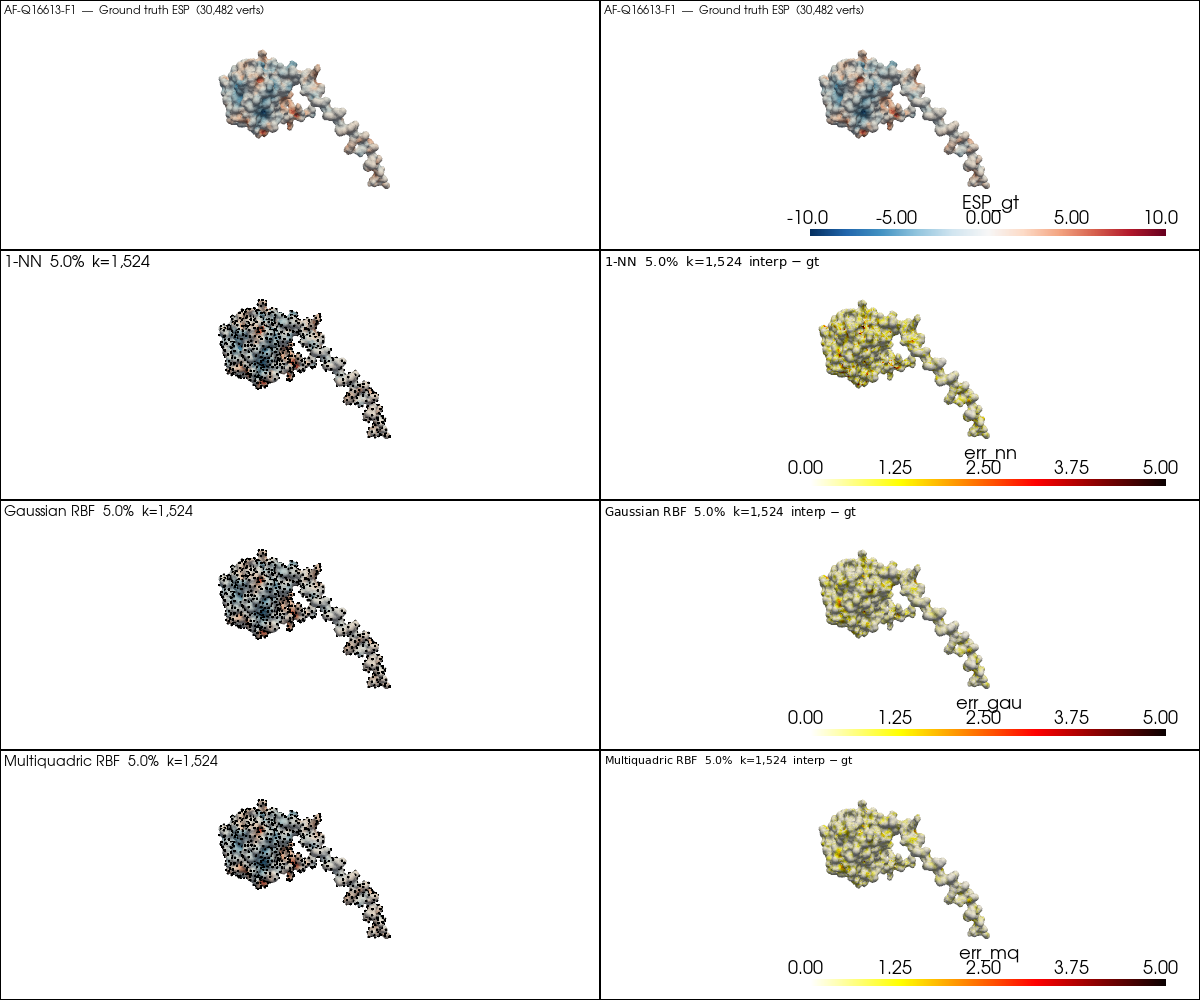

In [12]:
# ── Build visualisation at SAMPLE_FRAC ──────────────────────────────────────
k_viz         = max(1, round(SAMPLE_FRAC * len(verts)))
rng_viz       = np.random.default_rng(RNG_SEED)
idx_viz, _    = sample_curvature(verts, curv, k_viz, ses_area, rng_viz)
esp_known_viz = esp_gt[idx_viz]

print(f"k={k_viz:,} of {len(verts):,} vertices ({SAMPLE_FRAC*100:.1f}%)")

esp_nn,  t_nn  = interp_nearest_neighbor(verts, esp_known_viz, idx_viz)
esp_gau, t_gau = interp_gaussian_rbf(verts, esp_known_viz, idx_viz)
esp_mq,  t_mq  = interp_multiquadric_rbf(verts, esp_known_viz, idx_viz)

for lbl, esp, t in [
    ("1-NN",         esp_nn,  t_nn),
    ("Gaussian RBF", esp_gau, t_gau),
    ("Multiquadric", esp_mq,  t_mq),
]:
    r, _ = pearsonr(esp_gt.astype(float), esp.astype(float))
    rmse = float(np.sqrt(np.mean((esp_gt - esp) ** 2)))
    print(f"  {lbl:20s}  r={r:.4f}  rmse={rmse:.4f}  t={t:.2f}s")


def make_mesh(v, f, scalar, name):
    pad   = np.full((len(f), 1), 3, dtype=int)
    cells = np.hstack([pad, f]).ravel()
    surf  = pv.PolyData(v, cells); surf[name] = scalar; return surf


mesh_gt      = make_mesh(verts, faces, esp_gt,                    "ESP_gt")
mesh_nn      = make_mesh(verts, faces, esp_nn,                    "ESP_nn")
mesh_gau     = make_mesh(verts, faces, esp_gau,                   "ESP_gau")
mesh_mq      = make_mesh(verts, faces, esp_mq,                    "ESP_mq")
mesh_err_nn  = make_mesh(verts, faces, np.abs(esp_nn  - esp_gt), "err_nn")
mesh_err_gau = make_mesh(verts, faces, np.abs(esp_gau - esp_gt), "err_gau")
mesh_err_mq  = make_mesh(verts, faces, np.abs(esp_mq  - esp_gt), "err_mq")
pts_sample   = pv.PolyData(verts[idx_viz])

pl = pv.Plotter(shape=(4, 2), window_size=(1200, 1000), off_screen=True)
pl.set_background("white")

# Row 0: ground truth
for col in range(2):
    pl.subplot(0, col)
    pl.add_mesh(mesh_gt, scalars="ESP_gt", cmap=COLORMAP, clim=CLIM,
                show_scalar_bar=(col == 1))
    pl.add_text(f"{pid}  —  Ground truth ESP  ({len(verts):,} verts)",
               font_size=8, color="black")
    pl.camera_position = CAMERA

# Rows 1–3
for row, mesh_e, sname_e, mesh_err, sname_err, label in [
    (1, mesh_nn,  "ESP_nn",  mesh_err_nn,  "err_nn",  f"1-NN  {SAMPLE_FRAC*100:.1f}%  k={k_viz:,}"),
    (2, mesh_gau, "ESP_gau", mesh_err_gau, "err_gau", f"Gaussian RBF  {SAMPLE_FRAC*100:.1f}%  k={k_viz:,}"),
    (3, mesh_mq,  "ESP_mq",  mesh_err_mq,  "err_mq",  f"Multiquadric RBF  {SAMPLE_FRAC*100:.1f}%  k={k_viz:,}"),
]:
    pl.subplot(row, 0)
    pl.add_mesh(mesh_e, scalars=sname_e, cmap=COLORMAP, clim=CLIM, show_scalar_bar=False)
    pl.add_points(pts_sample, color="black", point_size=3, render_points_as_spheres=True)
    pl.add_text(label, font_size=8, color="black")
    pl.camera_position = CAMERA
    pl.subplot(row, 1)
    pl.add_mesh(mesh_err, scalars=sname_err, cmap=ERR_CMAP, clim=ERR_CLIM, show_scalar_bar=True)
    pl.add_text(label + "  |interp − gt|", font_size=8, color="black")
    pl.camera_position = CAMERA

img = pl.screenshot(return_img=True)
pl.close()

buf = io.BytesIO()
PIL.Image.fromarray(img).save(buf, format="PNG")
out_path = OUT_DIR / f"{pid}_interpolation_viz_{SAMPLE_FRAC*100:.0f}pct.png"
PIL.Image.fromarray(img).save(out_path)
print(f"Saved → {out_path}")
ipy_display(ipy_Image(data=buf.getvalue(), format="png"))

---
## Notes & Observations

**1-NN vs RBF — accuracy at 5%:**
- 1-NN r=0.954, RMSE=0.766 kT/e. The piecewise-constant interpolation leaves hard transitions at Voronoi boundaries between samples, producing a blocky reconstruction that loses fine-grained surface features.
- Both RBF methods offer meaningful improvement: Gaussian r=0.978 (+0.024), Multiquadric r=0.983 (+0.029). The 39% RMSE reduction from multiquadric (0.766 → 0.466 kT/e) is significant for a training target — reducing this error means the model sees a smoother, more physically accurate ESP field.

**Gaussian vs Multiquadric RBF:**
- Multiquadric is strictly better on both metrics (r=0.983 vs 0.978; RMSE=0.466 vs 0.548) at essentially identical compute time (1.121s vs 1.143s).
- The Gaussian kernel exp(−(εr)²) decays sharply — it interpolates well near samples but falls off quickly between them. The multiquadric kernel √(1+(εr)²) has slower algebraic decay, which better captures the longer-range variation in ESP fields where influence between charged residues extends several Ångströms.

**Compute cost — is RBF worth it?**
- Both RBF methods are ~230× slower than 1-NN (1.12s vs 0.005s at k=1,524). For a one-time preprocessing step on a per-protein basis this is acceptable. It would not be suitable as an in-loop reconstruction during model inference.
- `neighbors=50` local support keeps cost manageable — without this the full N×k system would be far more expensive.

**How does accuracy scale with fraction?**
- This notebook runs at the chosen 5% only. Scaling behavior across fractions was characterized in `03_vertex_sampling_strategy.ipynb` using 1-NN as the reconstruction method. RBF gains are expected to be similar or larger at lower fractions (fewer samples → more benefit from smooth interpolation over 1-NN jumps).

**Decision: Multiquadric RBF reconstruction from curvature-weighted 5% subsample.**

In [ ]:
# ── Interactive window (terminal) ─────────────────────────────────────────────
import pickle, subprocess, textwrap, tempfile

_data = {
    "verts": verts, "faces": faces, "esp_gt": esp_gt,
    "esp_nn": esp_nn, "esp_gau": esp_gau, "esp_mq": esp_mq,
    "idx_viz": idx_viz, "pid": pid, "k_viz": k_viz,
    "SAMPLE_FRAC": SAMPLE_FRAC,
    "CLIM": CLIM, "ERR_CLIM": ERR_CLIM,
    "COLORMAP": COLORMAP, "ERR_CMAP": ERR_CMAP, "CAMERA": CAMERA,
}
_pkl = tempfile.NamedTemporaryFile(suffix=".pkl", delete=False)
pickle.dump(_data, open(_pkl.name, "wb"))

_script = textwrap.dedent(f"""
    import pickle, numpy as np, pyvista as pv
    d = pickle.load(open({repr(_pkl.name)}, 'rb'))
    verts, faces = d['verts'], d['faces']
    esp_gt, esp_nn, esp_gau, esp_mq = d['esp_gt'], d['esp_nn'], d['esp_gau'], d['esp_mq']
    idx_viz = d['idx_viz']
    pid, k_viz, frac = d['pid'], d['k_viz'], d['SAMPLE_FRAC']
    CLIM, ERR_CLIM = d['CLIM'], d['ERR_CLIM']
    COLORMAP, ERR_CMAP, CAM = d['COLORMAP'], d['ERR_CMAP'], d['CAMERA']
    def make_mesh(v, f, s, name):
        pad = np.full((len(f), 1), 3, dtype=int)
        cells = np.hstack([pad, f]).ravel()
        m = pv.PolyData(v, cells); m[name] = s; return m
    panels = [
        (make_mesh(verts, faces, esp_gt,                    'ESP_gt'),  'ESP_gt',  COLORMAP, CLIM,     None,            f'Ground truth'),
        (make_mesh(verts, faces, esp_gt,                    'ESP_gt2'), 'ESP_gt2', COLORMAP, CLIM,     None,            'Ground truth (copy)'),
        (make_mesh(verts, faces, esp_nn,                    'ESP_nn'),  'ESP_nn',  COLORMAP, CLIM,     pv.PolyData(verts[idx_viz]), f'1-NN {{frac*100:.1f}}% k={{k_viz}}'),
        (make_mesh(verts, faces, np.abs(esp_nn -esp_gt),   'err_nn'),  'err_nn',  ERR_CMAP, ERR_CLIM, None,            '1-NN |err|'),
        (make_mesh(verts, faces, esp_gau,                   'ESP_gau'), 'ESP_gau', COLORMAP, CLIM,     pv.PolyData(verts[idx_viz]), f'Gaussian RBF {{frac*100:.1f}}% k={{k_viz}}'),
        (make_mesh(verts, faces, np.abs(esp_gau-esp_gt),   'err_gau'), 'err_gau', ERR_CMAP, ERR_CLIM, None,            'Gaussian RBF |err|'),
        (make_mesh(verts, faces, esp_mq,                    'ESP_mq'),  'ESP_mq',  COLORMAP, CLIM,     pv.PolyData(verts[idx_viz]), f'Multiquadric {{frac*100:.1f}}% k={{k_viz}}'),
        (make_mesh(verts, faces, np.abs(esp_mq -esp_gt),   'err_mq'),  'err_mq',  ERR_CMAP, ERR_CLIM, None,            'Multiquadric |err|'),
    ]
    pl = pv.Plotter(shape=(4,2), window_size=(1200,1000))
    pl.set_background('white')
    for ci, (mesh, sname, cmap, clim, pts, title) in enumerate(panels):
        pl.subplot(ci//2, ci%2)
        pl.add_mesh(mesh, scalars=sname, cmap=cmap, clim=clim, show_scalar_bar=(ci%2==1))
        if pts is not None:
            pl.add_points(pts, color='black', point_size=3, render_points_as_spheres=True)
        pl.add_text(title, font_size=8, color='black')
        pl.camera_position = CAM
    pl.link_views()
    pl.show(title=f'{{pid}} — Interpolation {{frac*100:.1f}}% k={{k_viz}}')
""")
_script_file = tempfile.NamedTemporaryFile(suffix=".py", delete=False, mode="w")
_script_file.write(_script); _script_file.close()
subprocess.Popen(["bash", "-c", f"DISPLAY=:0 conda run -n protein_esp python {_script_file.name}"])
print("Launched interactive window in terminal.")

Launched interactive window in terminal.
